# 1. Libraries

In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn.objects as so

from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from IPython.display import Markdown as md

# 2. Data load

In [105]:
df_raw = pd.read_csv("data/Loan_default.csv", delimiter=",", low_memory=False)

In [106]:
# To avoid modifying the original dataset
df = df_raw.copy()

# 3. EDA

## 3.1. KDE

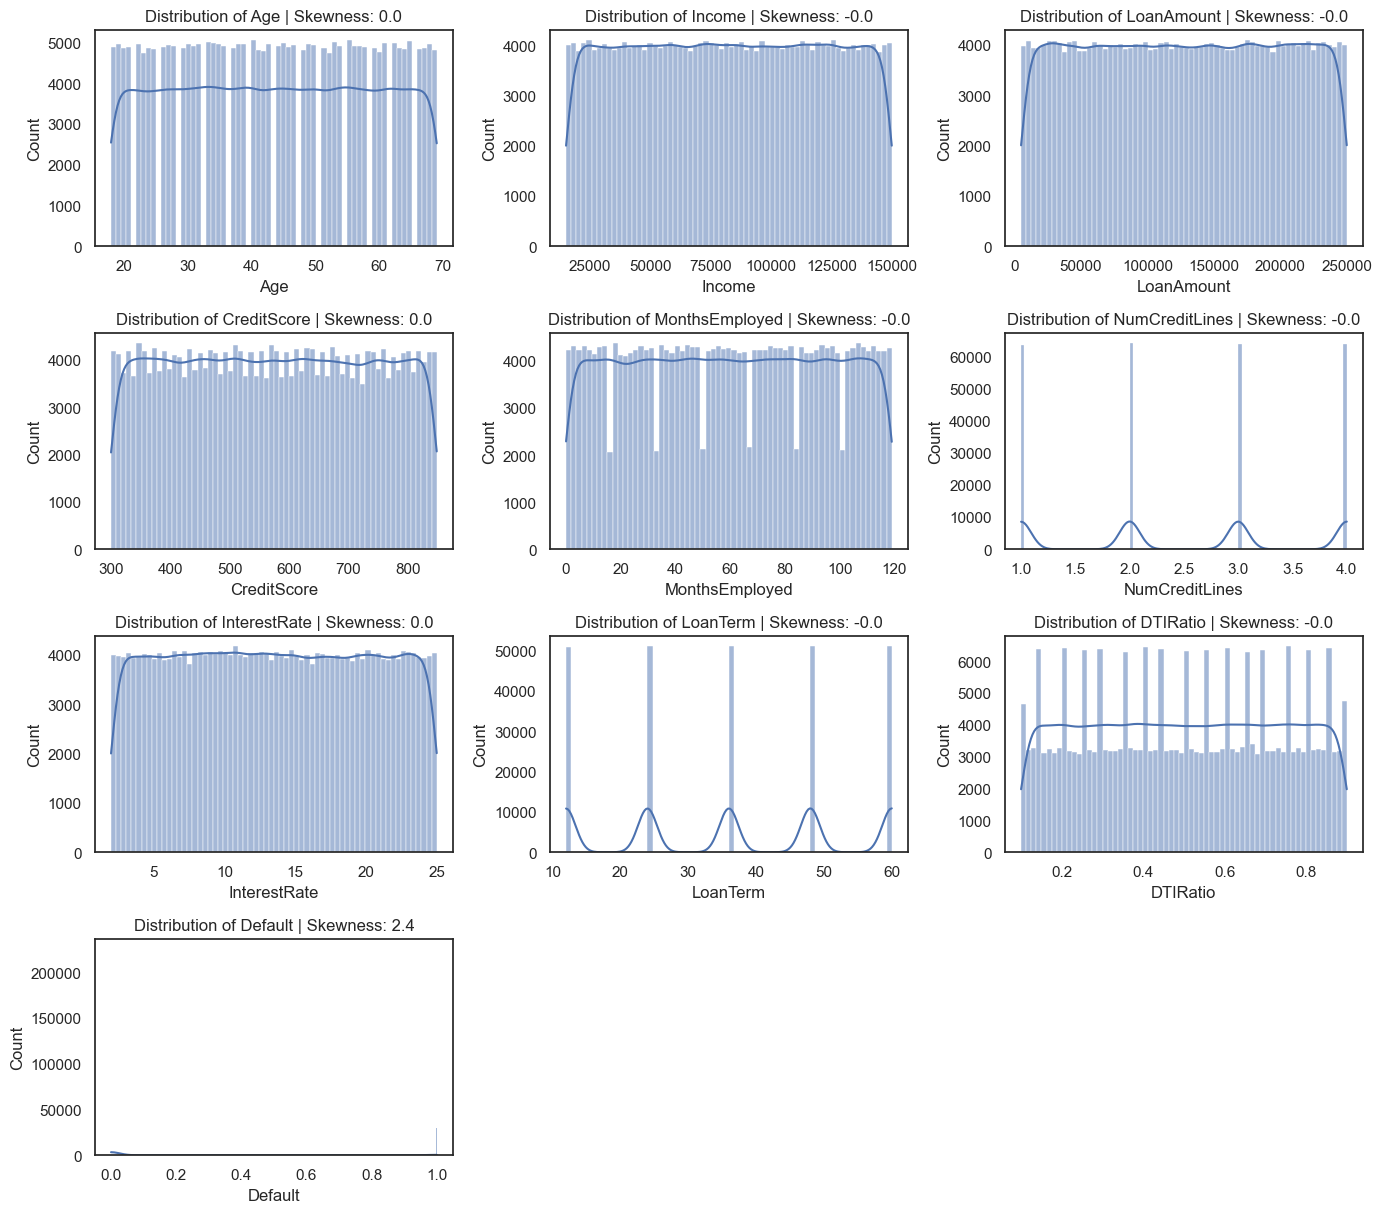

In [107]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns):
    plt.subplot(len(numerical_columns), 3, idx + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature} | Skewness: {round(df[feature].skew(),2)}")
plt.tight_layout()
plt.show()

Data is uniform, no significant skewness observed in numerical features


## 3.2. Basic stats

In [108]:
# quick info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [109]:
# null values in each column
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [110]:
# data preview
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [111]:
# unique values % share
round((df.nunique() / df.count()) * 100,2)

LoanID            100.00
Age                 0.02
Income             44.89
LoanAmount         62.16
CreditScore         0.22
MonthsEmployed      0.05
NumCreditLines      0.00
InterestRate        0.90
LoanTerm            0.00
DTIRatio            0.03
Education           0.00
EmploymentType      0.00
MaritalStatus       0.00
HasMortgage         0.00
HasDependents       0.00
LoanPurpose         0.00
HasCoSigner         0.00
Default             0.00
dtype: float64

In [112]:
# data types of each column
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [113]:
# primary key check
df["LoanID"].nunique() == df.shape[0]

True

In [114]:
# category columns with 5 or fewer unique values
base = df.select_dtypes(include=["object"]).nunique()
mask = df.select_dtypes(include=["object"]).nunique() <=5

category_columns = base[mask]
category_columns = category_columns.reset_index().rename(columns={"index" : "CategoryColumns"})["CategoryColumns"]
category_columns

0         Education
1    EmploymentType
2     MaritalStatus
3       HasMortgage
4     HasDependents
5       LoanPurpose
6       HasCoSigner
Name: CategoryColumns, dtype: object

In [115]:
for col in df.columns:
    if col in category_columns.values:
        df[col] = df[col].astype("category")

In [116]:
# statistical summary of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


The data does not show any significant linear relationships between variables. Most correlation coefficients are close to zero.

There are some signals in the Default column, but they are weak:

InterestRate: positive correlation – higher interest rates are associated with a higher risk of default.

Age, Income, MonthsEmployed: negative correlation – older people with higher incomes and longer employment histories are less likely to default on their obligations.

The other variables have a negligible linear relationship with Default and, in this respect, do not provide any significant information.

## 3.3. Correlation heatmap

In [117]:
correlation_matrix = df.corr(numeric_only=True, method="pearson")

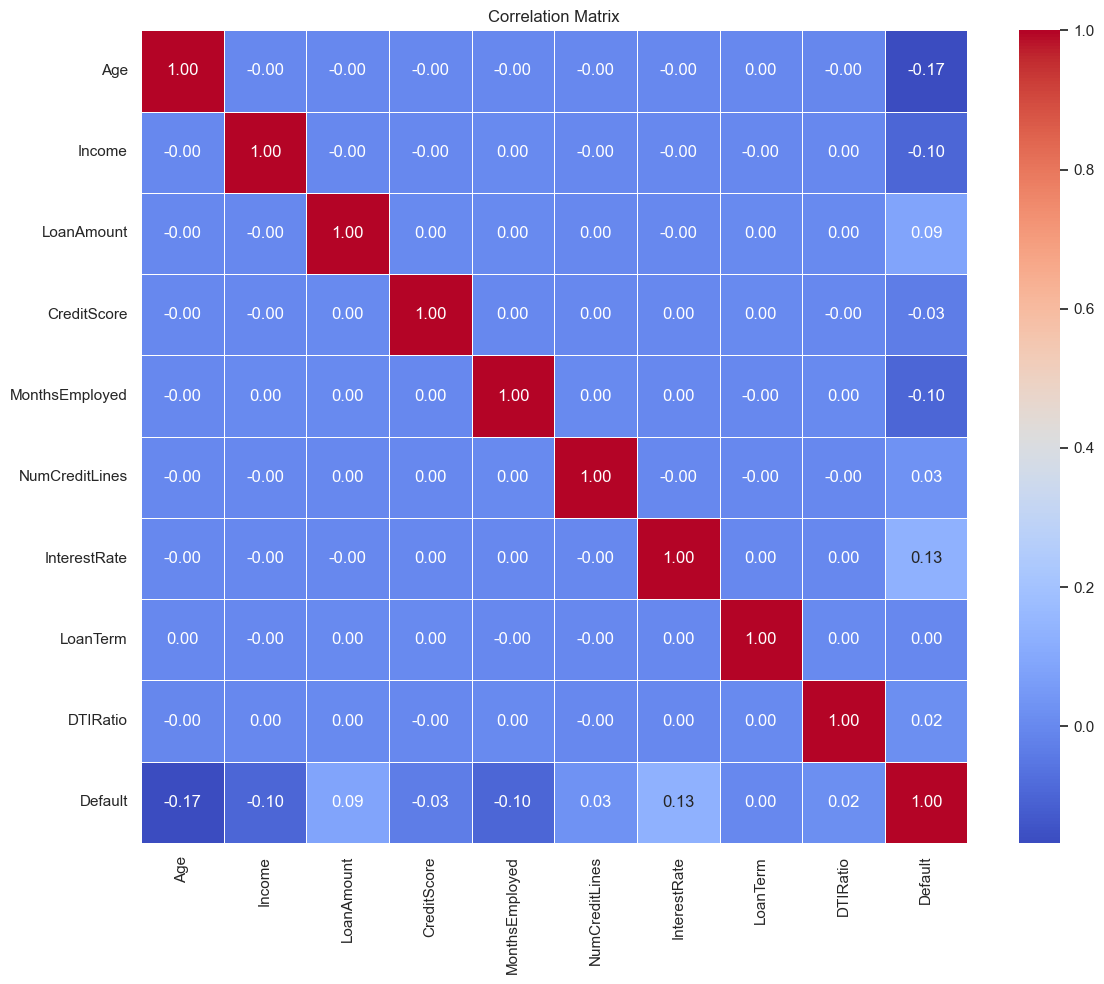

In [118]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

**Note that the Default column takes two values: 0 or 1, so the matrix can be treated as a guideline rather than definitive proof of the existence or absence of correlation.**

* The data does not show any significant linear relationships between variables. Most correlation coefficients are close to zero.

* There are some signals in the **Default** column, but they are weak:
    * **InterestRate**: positive correlation; higher interest rates are associated with a higher risk of default.
    * **Age**, **Income**, **MonthsEmployed**: negative correlation; older people with higher incomes and longer employment histories are less likely to default on their obligations.

* The other variables have a negligible linear relationship with Default and, in this respect, do not provide any significant information.

Example for Default/Age/Marital status. It is clear that Default and age are related in such a way that Default goes with younger age. The median Default is lower than that of Repaid loans.

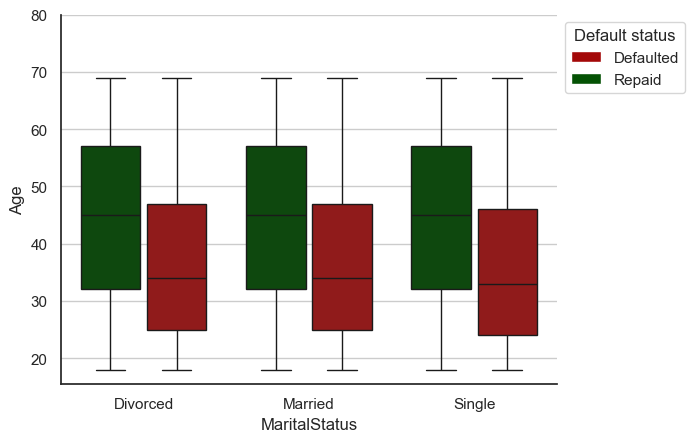

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

palette = ["#045204", "#A30808"]

ax = sns.boxplot(
    data=df,
    x="MaritalStatus",
    y="Age",
    hue="Default",
    gap=.1,
    palette={1: palette[1], 0: palette[0]},
    legend=False
)

ax.set(yticks=[20, 30, 40, 50, 60, 70, 80])


ax.grid(True, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = [
    Patch(facecolor=palette[1], label="Defaulted"),
    Patch(facecolor=palette[0], label="Repaid")
]

ax.legend(
    handles=legend_handles, 
    title="Default status", 
    loc="upper left", 
    bbox_to_anchor=(1, 1)
)

# 4. Questions

## 4.1. What percentage of loan applications end in default? How does this vary between marital status, education, and employment type?

### 4.1.1. Marital Status

In [120]:
MaritalStatusGrouped = df.groupby("MaritalStatus", as_index=False, group_keys=False, observed=False)[["Default", "MaritalStatus"]]. \
    agg( DefaultCount=("Default", "sum"), GroupCount=("MaritalStatus", "count"))
MaritalStatusGrouped["Ratio"] = (MaritalStatusGrouped["DefaultCount"] / MaritalStatusGrouped["GroupCount"]).round(2) * 100

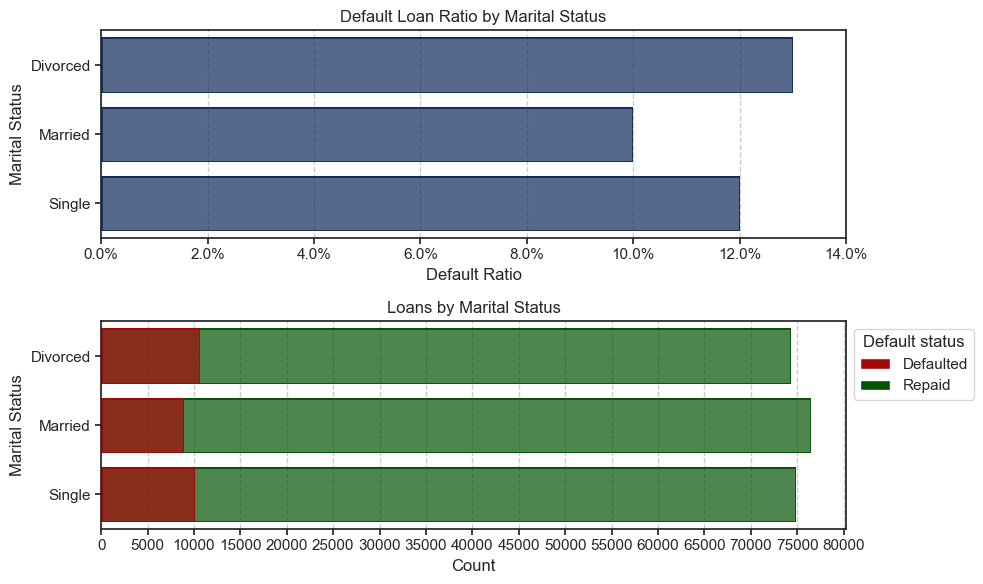

In [121]:
sns.set_theme(
    style="white"
    )
f, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 6))
palette = ["#045204", "#A30808"]

(
    so.Plot(
        data=MaritalStatusGrouped,
        x="Ratio",
        y="MaritalStatus"
        )       
    .add(
        so.Bar(
            color="#102a58"
            )
        )
    .scale(
        x=so.Continuous().tick(every=2).label(like="{x}%")
        )
    .limit(
        x=(0, MaritalStatusGrouped["Ratio"].max() + 1)
    )
    .label(
        title="Default Loan Ratio by Marital Status",
        x="Default Ratio",
        y="Marital Status",
        legend=False
        )
    .on(ax1)
    .plot()
)

(
    so.Plot(
        data=df,
        y="MaritalStatus",
        color="Default"
        )       
    .add(
        so.Bar(),
        so.Hist()
        )
    .scale(
        x=so.Continuous().tick(every=5000),
        color=so.Nominal({1:palette[1], 0:palette[0]}, order=[1,0])
        )
    .label(
        title="Loans by Marital Status",
        x="Count",
        y="Marital Status"
        )
    .on(ax2)
    .plot()
)

f.legends = []

ax1.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.xaxis.grid(True, linestyle="--", alpha=1)
ax1.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=palette[1], label="Defaulted"),
    Patch(facecolor=palette[0], label="Repaid")
]
ax2.legend(
    handles=legend_handles, 
    title="Default status", 
    loc="upper left", 
    bbox_to_anchor=(1, 1)
)

ax2.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.xaxis.grid(True, linestyle="--", alpha=1)
ax2.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.set_axisbelow(True)

plt.tight_layout()
palette = sns.color_palette()
plt.show()

In [122]:
display(MaritalStatusGrouped)

,MaritalStatus,DefaultCount,GroupCount,Ratio
0,Divorced,10657,85033,13.0
1,Married,8869,85302,10.0
2,Single,10127,85012,12.0


The percentage of unpaid loans is lowest among married people. This may correlate with age, life stability, but also with the spouses' joint contribution to the budget.

### 4.1.2. Education

In [123]:
EducationGrouped = df.groupby("Education", as_index=False, group_keys=False, observed=False)[["Default", "Education"]]. \
    agg(DefaultCount=("Default", "sum"), GroupCount=("Education", "count"))
EducationGrouped["Ratio"] = (EducationGrouped["DefaultCount"] / EducationGrouped["GroupCount"]).round(2) * 100

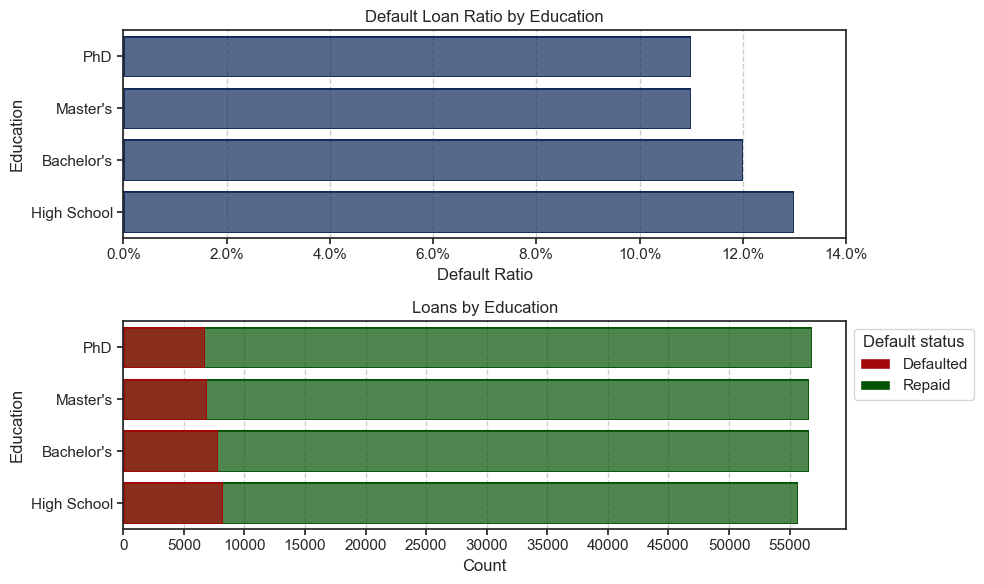

In [124]:
sns.set_theme(
    style="white"
    )
f, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 6))
palette = ["#045204", "#A30808"]
education_order = ["PhD", "Master's", "Bachelor's", "High School"]

(
    so.Plot(
        data=EducationGrouped,
        x="Ratio",
        y="Education"
        )       
    .add(
        so.Bar(
            color="#102a58"
            )
        )
    .scale(
        x=so.Continuous().tick(every=2).label(like="{x}%"),
        y=so.Nominal(order=education_order)
        )
    .limit(
        x=(0, EducationGrouped["Ratio"].max() + 1)
    )
    .label(
        title="Default Loan Ratio by Education",
        x="Default Ratio",
        y="Education",
        legend=False
        )
    .on(ax1)
    .plot()
)

(
    so.Plot(
        data=df,
        y="Education",
        color="Default"
        )       
    .add(
        so.Bar(),
        so.Hist()
        )
    .scale(
        x=so.Continuous().tick(every=5000),
        color=so.Nominal({1:palette[1], 0:palette[0]}, order=[1,0]),
        y=so.Nominal(order=education_order)
        )
    .label(
        title="Loans by Education",
        x="Count",
        y="Education"
        )
    .on(ax2)
    .plot()
)

f.legends = []

ax1.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.xaxis.grid(True, linestyle="--", alpha=1)
ax1.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=palette[1], label="Defaulted"),
    Patch(facecolor=palette[0], label="Repaid")
]
ax2.legend(
    handles=legend_handles, 
    title="Default status", 
    loc="upper left", 
    bbox_to_anchor=(1, 1)
)

ax2.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.xaxis.grid(True, linestyle="--", alpha=1)
ax2.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.set_axisbelow(True)

plt.tight_layout()
palette = sns.color_palette()
plt.show()

The higher the level of education, the lower the default loan. This can be linked to the fact that higher education means better jobs, higher earnings, and higher material status.

In [125]:
EmploymentTypeGrouped = df.groupby("EmploymentType", as_index=False, group_keys=False, observed=False)[["Default", "EmploymentType"]]. \
    agg(DefaultCount=("Default", "sum"), GroupCount=("EmploymentType", "count"))
EmploymentTypeGrouped["Ratio"] = (EmploymentTypeGrouped["DefaultCount"] / EmploymentTypeGrouped["GroupCount"]).round(2) * 100

In [126]:
EmploymentTypeGrouped

,EmploymentType,DefaultCount,GroupCount,Ratio
0,Full-time,6024,63656,9.0
1,Part-time,7677,64161,12.0
2,Self-employed,7302,63706,11.0
3,Unemployed,8650,63824,14.0


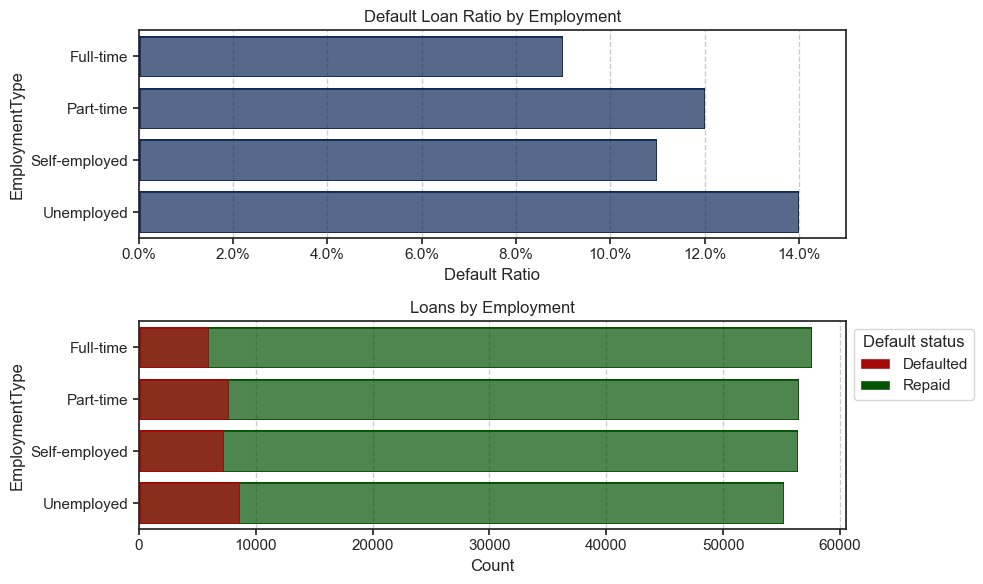

In [127]:
sns.set_theme(
    style="white"
    )
f, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 6))
palette = ["#045204", "#A30808"]
employment_order = ["Full-time", "Part-time", "Self-employed", "Unemployed"]

(
    so.Plot(
        data=EmploymentTypeGrouped,
        x="Ratio",
        y="EmploymentType"
        )       
    .add(
        so.Bar(color="#102a58")
        )
    .scale(
        x=so.Continuous().tick(every=2).label(like="{x}%"),
        y=so.Nominal(order=employment_order)
        )
    .limit(
        x=(0, EmploymentTypeGrouped["Ratio"].max() + 1)
    )
    .label(
        title="Default Loan Ratio by Employment",
        x="Default Ratio",
        y="EmploymentType",
        legend=False
        )
    .on(ax1)
    .plot()
)

(
    so.Plot(
        data=df,
        y="EmploymentType",
        color="Default"
        )       
    .add(
        so.Bar(),
        so.Hist()
        )
    .scale(
        # x=so.Continuous().tick(every=5000),
        color=so.Nominal({1:palette[1], 0:palette[0]}, order=[1,0]),
        y=so.Nominal(order=employment_order)
        )
    .label(
        title="Loans by Employment",
        x="Count",
        y="EmploymentType"
        )
    .on(ax2)
    .plot()
)

f.legends = []

ax1.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.xaxis.grid(True, linestyle="--", alpha=1)
ax1.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=palette[1], label="Defaulted"),
    Patch(facecolor=palette[0], label="Repaid")
]
ax2.legend(
    handles=legend_handles, 
    title="Default status", 
    loc="upper left", 
    bbox_to_anchor=(1, 1)
)

ax2.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.xaxis.grid(True, linestyle="--", alpha=1)
ax2.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.set_axisbelow(True)

plt.tight_layout()
palette = sns.color_palette()
plt.show()

The highest number of unpaid loans is among the unemployed, which is relatively obvious, as they have to support themselves on pensions/benefits/social assistance/help from relatives. Without stable income, the risk increases. The percentage of unpaid loans also increases significantly among part-time workers, which can be linked to job stability. In the event of sudden dismissal, which is possible in this group, there is a problem with meeting financial obligations.

## 4.2 What is the average loan amount? How does it differ between self-employed vs. employed vs. unemployed?

In [128]:
average_loan = df.groupby("EmploymentType", as_index=False, observed=False).agg(AverageLoan=("LoanAmount", "mean")).round(2)
LoanAmountAVG = df["LoanAmount"].mean().round(2)

In [129]:
display(md(f"{LoanAmountAVG} is average load amount in entire dataset"))

127578.87 is average load amount in entire dataset

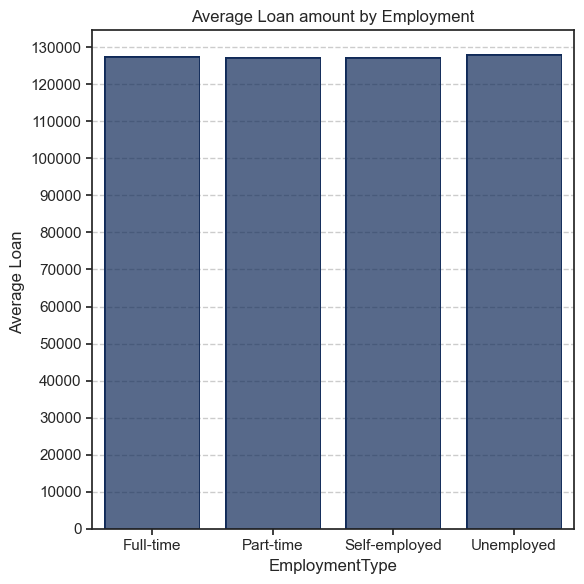

In [130]:
f, ax1 = plt.subplots(1,1, figsize=(6, 6))
palette = ["#045204", "#A30808"]
employment_order = ["Full-time", "Part-time", "Self-employed", "Unemployed"]

sns.set_theme(
    style="white"
    )
(    
    so.Plot(
        data=average_loan,
        x="EmploymentType",
        y="AverageLoan"
        )       
    .add(
        so.Bar(
            color="#102a58"
            )
        )
    .scale(
        x=so.Nominal(order=employment_order),
        y=so.Continuous().tick(every=10000).label(like="{x:.0f}")
        )
    .label(
        title="Average Loan amount by Employment",
        x="EmploymentType",
        y="Average Loan ",
        legend=False
        )
    .on(ax1)
    .plot()

)

f.legends = []

ax1.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.yaxis.grid(True, linestyle="--", alpha=1)
ax1.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.set_axisbelow(True)

plt.tight_layout()
palette = sns.color_palette()
plt.show()

In [131]:
average_loan

,EmploymentType,AverageLoan
0,Full-time,127469.87
1,Part-time,127329.70
2,Self-employed,127436.70
3,Unemployed,128079.96


### Answer

There are no significant differences in the amount of loans granted to individual employment groups

## 4.3. Do people with higher incomes get higher loans?

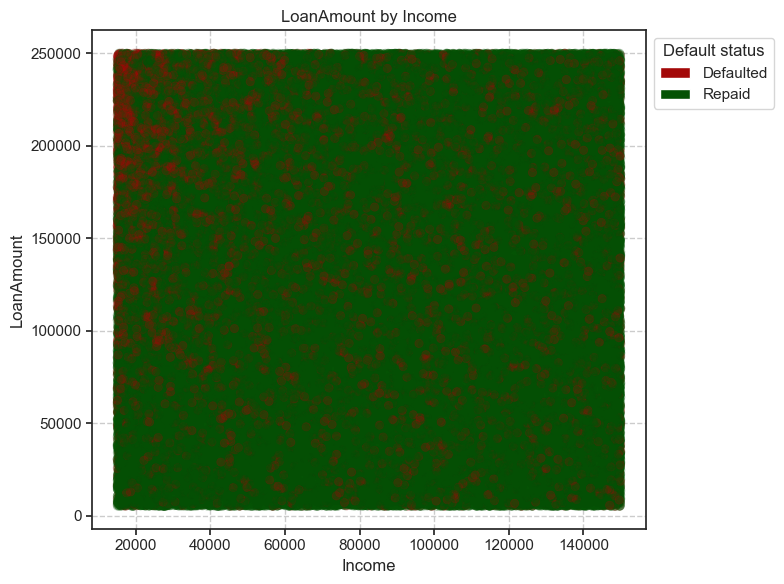

In [132]:
sns.set_theme(
    style="white"
    )
f, ax1 = plt.subplots(1,1, figsize=(8, 6))
palette = ["#045204", "#A30808"]
employment_order = ["Full-time", "Part-time", "Self-employed", "Unemployed"]

(
    
    so.Plot(
        data=df,
        x="Income",
        y="LoanAmount",
        color="Default"
        )       
    .add(
        so.Dot(
            alpha=0.25
            )
        )
    .scale(
        x=so.Continuous().tick(every=20000).label(like="{x:.0f}"),
        y=so.Continuous().tick(every=50000).label(like="{x:.0f}"),
        color=so.Nominal({1: palette[1], 0: palette[0]})
        )
    .label(
        title="LoanAmount by Income",
        x="Income",
        y="LoanAmount",
        legend=False
        )
    .on(ax1)
    .plot()
)

f.legends = []

ax1.xaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.xaxis.grid(True, linestyle="--", alpha=1)
ax1.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.yaxis.grid(True, linestyle="--", alpha=1)
ax1.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=palette[1], label="Defaulted"),
    Patch(facecolor=palette[0], label="Repaid")
]
ax1.legend(
    handles=legend_handles, 
    title="Default status", 
    loc="upper left", 
    bbox_to_anchor=(1, 1)
)

plt.tight_layout()
palette = sns.color_palette()
plt.show()

### Answer

The graph does not show that people with higher incomes receive higher loans; the scatterplot is a perfect square. But it can be seen that there are more unpaid loans in the low-income and high-loan value ranges. This is fairly obvious: low incomes were unable to cover the obligations of high loans.

## 4.4 Profile of a typical "defaulted" vs. "non-defaulted" borrower. What distinguishes them?

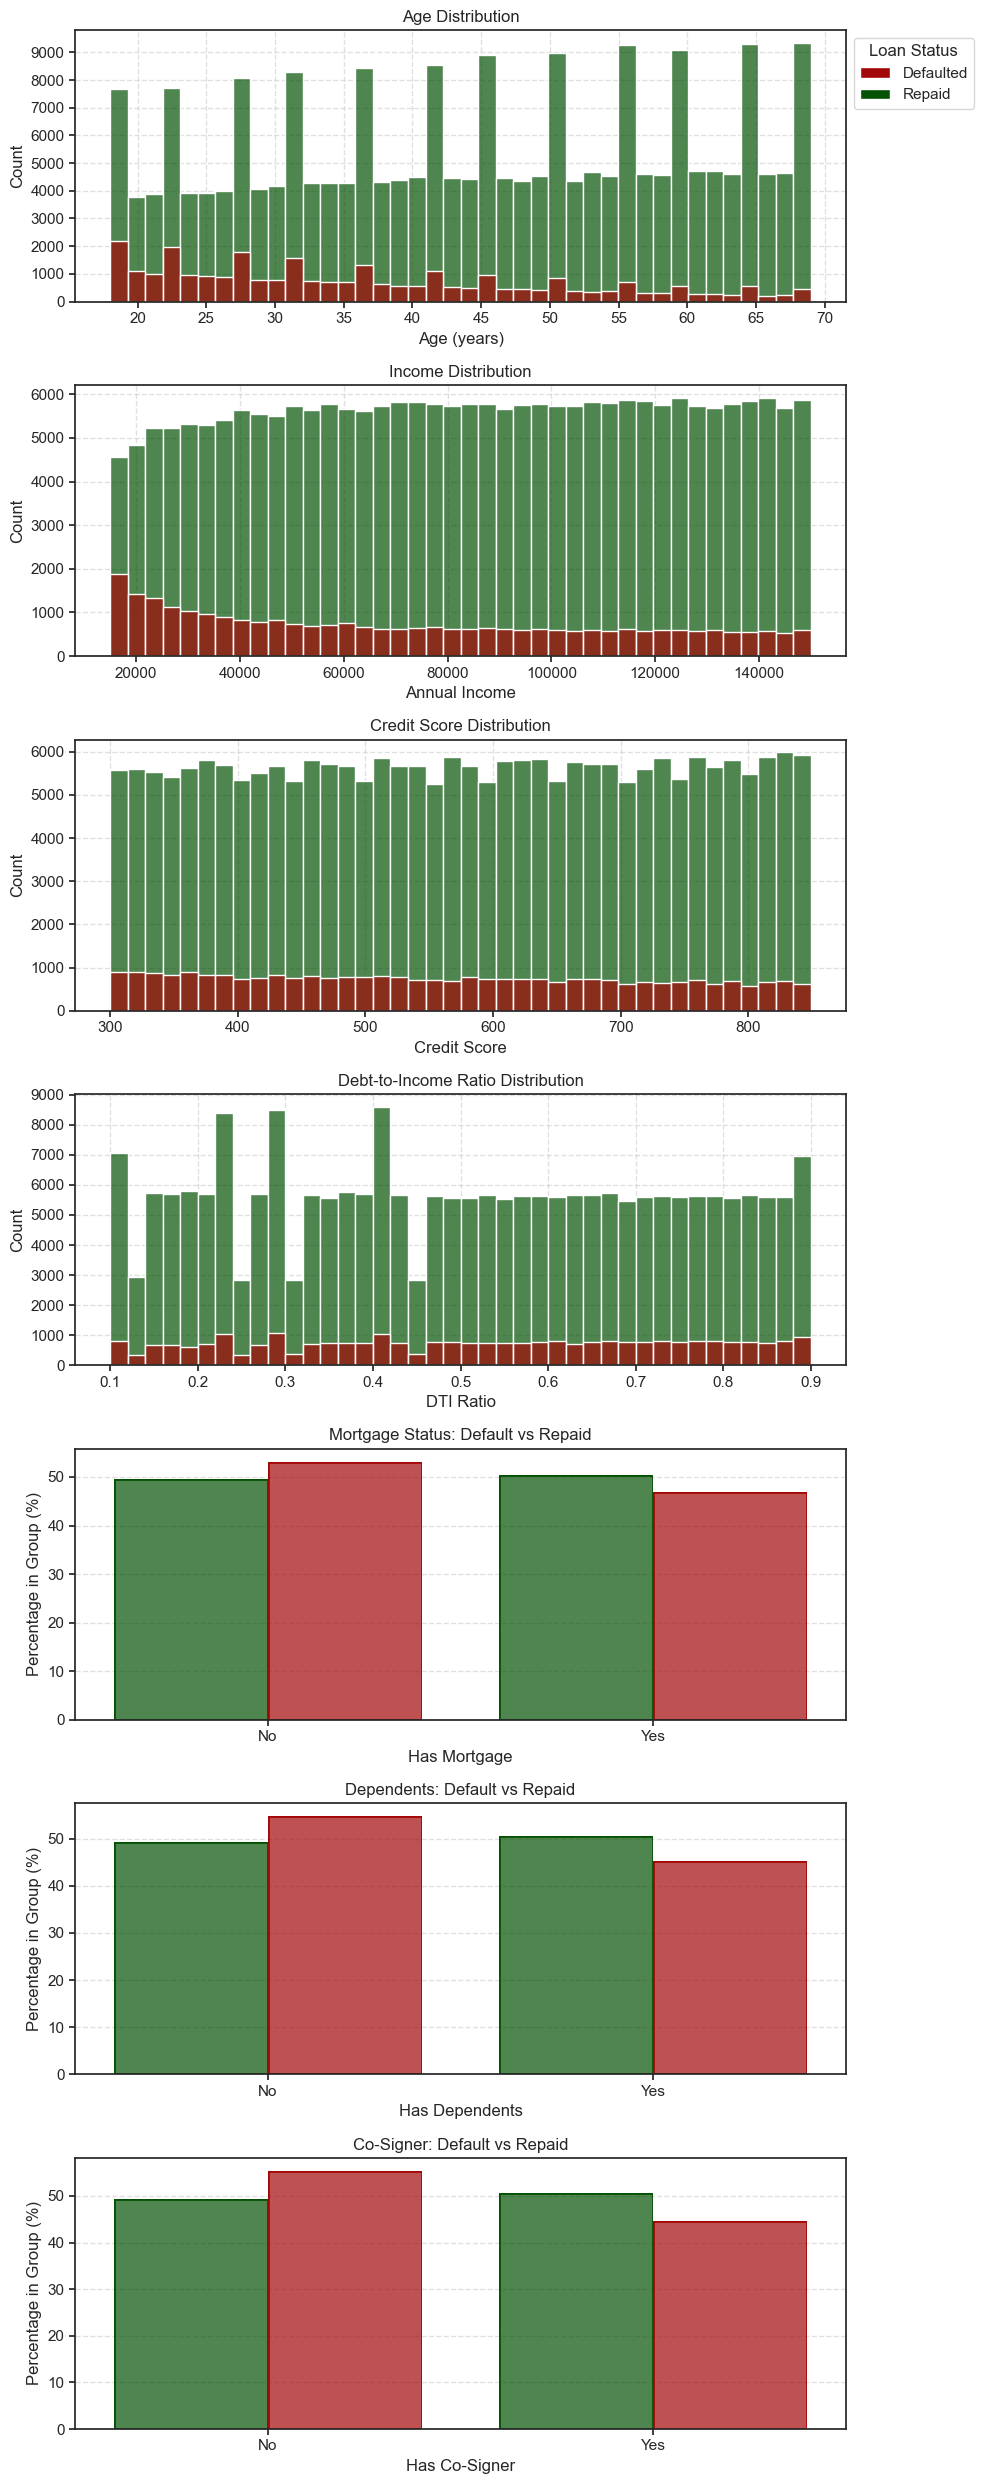

In [133]:
sns.set_theme(style="white")
f, (ax1, ax2, ax3, ax4, ax5, ax6, ax7) = plt.subplots(7, 1, figsize=(10, 25))
palette = ["#045204", "#A30808"] # Zielony (0), Czerwony (1)



# AX1: Age
(
    so.Plot(data=df, x="Age", color="Default")
    .add(so.Bars(), so.Hist(bins=40))
    .scale(
        x=so.Continuous().tick(every=5).label(like="{x:.0f}"),
        y=so.Continuous().tick(every=1000).label(like="{x:.0f}"),
        color=so.Nominal({1: palette[1], 0: palette[0]})
    )
    .label(title="Age Distribution", x="Age (years)", y="Count", legend=False)
    .on(ax1).plot()
)

# AX2: Income
(
    so.Plot(data=df, x="Income", color="Default")
    .add(so.Bars(), so.Hist(bins=40))
    .scale(
        x=so.Continuous().tick(every=20000).label(like="{x:.0f}"),
        y=so.Continuous().tick(every=1000).label(like="{x:.0f}"),
        color=so.Nominal({1: palette[1], 0: palette[0]})
    )
    .label(title="Income Distribution", x="Annual Income", y="Count", legend=False)
    .on(ax2).plot()
)

# AX3: CreditScore
(
    so.Plot(data=df, x="CreditScore", color="Default")
    .add(so.Bars(), so.Hist(bins=40))
    .scale(
        x=so.Continuous().tick(every=100).label(like="{x:.0f}"),
        y=so.Continuous().tick(every=1000).label(like="{x:.0f}"),
        color=so.Nominal({1: palette[1], 0: palette[0]})
    )
    .label(title="Credit Score Distribution", x="Credit Score", y="Count", legend=False)
    .on(ax3).plot()
)

# AX4: DTIRatio (Debt-to-Income)
(
    so.Plot(data=df, x="DTIRatio", color="Default")
    .add(so.Bars(), so.Hist(bins=40))
    .scale(
        x=so.Continuous().tick(every=0.1).label(like="{x:.1f}"), # Poprawione na jedno miejsce po przecinku
        y=so.Continuous().tick(every=1000).label(like="{x:.0f}"),
        color=so.Nominal({1: palette[1], 0: palette[0]})
    )
    .label(title="Debt-to-Income Ratio Distribution", x="DTI Ratio", y="Count", legend=False)
    .on(ax4).plot()
)

# AX5: HasMortgage
(
    so.Plot(df, x="HasMortgage", color="Default")
    .add(so.Bar(), so.Hist(stat="percent", common_norm=False), so.Dodge())
    .scale(color=so.Nominal({1: palette[1], 0: palette[0]}))
    .label(title="Mortgage Status: Default vs Repaid", x="Has Mortgage", y="Percentage in Group (%)", legend=False)
    .on(ax5).plot()
)

# AX6: HasDependents
(
    so.Plot(df, x="HasDependents", color="Default")
    .add(so.Bar(), so.Hist(stat="percent", common_norm=False), so.Dodge())
    .scale(color=so.Nominal({1: palette[1], 0: palette[0]}))
    .label(title="Dependents: Default vs Repaid", x="Has Dependents", y="Percentage in Group (%)", legend=False)
    .on(ax6).plot()
)

# AX7: HasCoSigner
(
    so.Plot(df, x="HasCoSigner", color="Default")
    .add(so.Bar(), so.Hist(stat="percent", common_norm=False), so.Dodge())
    .scale(color=so.Nominal({1: palette[1], 0: palette[0]}))
    .label(title="Co-Signer: Default vs Repaid", x="Has Co-Signer", y="Percentage in Group (%)", legend=False)
    .on(ax7).plot()
)

axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]

for ax in axes:
    ax.xaxis.set_tick_params(which="both", left=True, length=4)
    ax.yaxis.set_tick_params(which="both", left=True, length=4)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    if ax in [ax1, ax2, ax3, ax4]:
        ax.xaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)


f.legends = []
legend_handles = [
    Patch(facecolor=palette[1], label="Defaulted"),
    Patch(facecolor=palette[0], label="Repaid")
]
ax1.legend(
    handles=legend_handles, 
    title="Loan Status", 
    loc="upper left", 
    bbox_to_anchor=(1, 1)
)

plt.tight_layout()
plt.show()

### Answer

The main risk factors in the analyzed set are age and income level. Behavioral and financial variables, such as credit score and DTI, have a marginal impact on the separation of groups.

## 4.5. Which combination of characteristics (income + loan amount + credit score + DTI) poses the highest risk of default?

In [134]:
df['LoanToIncome'] = df['LoanAmount'] / df['Income']

high_risk_mask = (
    (df['CreditScore'] < df['CreditScore'].quantile(0.75) ) & 
    (df['DTIRatio'] > df['DTIRatio'].quantile(0.75)) & 
    (df['LoanToIncome'] > df['LoanToIncome'].quantile(0.75))
)

df['Segment'] = 'Other'
df.loc[high_risk_mask, 'Segment'] = 'High Risk'

segment_analysis = (df.groupby('Segment')['Default'].mean() * 100).round(2)

segment_analysis

Segment
High Risk    19.84
Other        11.22
Name: Default, dtype: float64

### Answer

Even though we set fairly strict criteria for ‘high risk’, the risk of loan default in this group increases by only ~8.5%.

# 5. Summary

**Low risk variability across the portfolio.** \
The analysis shows very limited separation between clients who repay their loans and those who default. Even when applying a strict selection threshold, for example above the 75th percentile of the chosen risk metric, the difference in default rates is only about 8 percentage points. This indicates weak discriminatory power.


**Possible portfolio pre-selection or synthetic data** \
One likely explanation is prior client filtering by the bank. The portfolio may include only borrowers who already passed a strict verification process, which reduces natural risk variation. Another possibility is that the dataset is synthetic or has been pre-cleaned from extreme or high-risk cases.


**Income and age as the main risk drivers** \
Among all analyzed variables, two factors show a consistent relationship with default risk:
   - income level
   - borrower’s age 

Lower income and younger age are associated with a higher probability of default. However, even these variables do not create strong class separation.

**Limited value of other predictors** \
Financial and behavioral variables, including Credit Score and debt-related indicators, provide little additional discriminatory power. In this portfolio, their statistical impact is weak and operationally limited.